In [1]:
import numpy as np 
import pandas as pd

In [2]:
df = pd.read_csv('spam.csv' , encoding = 'latin1')


In [3]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
38,ham,Anything lor... U decide...,NaN,NaN,NaN
5282,ham,I have gone into get info bt dont know what to do,NaN,NaN,NaN
5005,ham,ILL B DOWN SOON,NaN,NaN,NaN
1455,spam,Summers finally here! Fancy a chat or flirt wi...,NaN,NaN,NaN
3786,ham,WHORE YOU ARE UNBELIEVABLE.,NaN,NaN,NaN


In [4]:
 df.shape

(5572, 5)

In [5]:
df.head(200)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
...,...,...,...,...,...
195,ham,Gud mrng dear hav a nice day,NaN,NaN,NaN
196,ham,Did u got that persons story,NaN,NaN,NaN
197,ham,is your hamster dead? Hey so tmr i meet you at...,NaN,NaN,NaN
198,ham,Hi its Kate how is your evening? I hope i can ...,NaN,NaN,NaN


In [6]:
df.shape

(5572, 5)

<h1> Data Cleaninng </h1>



In [7]:
## 1 Let start

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [9]:
df.drop(columns = ['Unnamed: 2','Unnamed: 3','Unnamed: 4'], inplace = True)

In [10]:
df.sample(5)

,v1,v2
4240,ham,Detroit. The home of snow. Enjoy it.
1844,ham,Da is good good player.why he is unsold.
2026,ham,"Nah man, my car is meant to be crammed full of..."
960,ham,U sure u can't take any sick time?
4065,ham,Fyi I'm gonna call you sporadically starting a...


In [11]:
# renaming the cols
df.rename(columns = {'v1' : 'target', 'v2':'text'} , inplace=True)

In [12]:
df.sample(5)

,target,text
5385,ham,How do friends help us in problems? They give ...
2520,ham,Misplaced your number and was sending texts to...
2021,ham,"I don't have anybody's number, I still haven't..."
1970,ham,Nvm it's ok...
2828,spam,Send a logo 2 ur lover - 2 names joined by a h...


In [13]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df['target'] = encoder.fit_transform(df['target'])

In [14]:
df.rename(columns={'v1':'target','v2':'text'}, inplace=True)

In [15]:
df.head()

,target,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [16]:
df.isnull().sum()

target    0
text      0
dtype: int64

In [17]:
# check for duplicate values
df = df.drop_duplicates(keep = 'first')

In [18]:
df.duplicated().sum()

0

In [19]:
df.shape

(5169, 2)

<h1>2.EDA</h1>

In [20]:
df.head()

,target,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [21]:
df['target'].value_counts()

target
ham     4516
spam     653
Name: count, dtype: int64

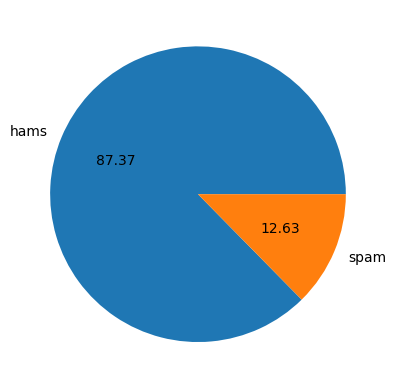

In [22]:
import matplotlib.pyplot as plt
plt.pie (df['target'].value_counts(), labels = ['hams','spam'] , autopct = '%0.2f')
plt.show()

In [23]:
# Data is Imbalance

In [24]:

! pip install nltk


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [25]:
import nltk
nltk.download('punkt')

NameError: name 'nltk' is not defined

In [26]:
df.loc[:, 'num_characters'] = df['text'].apply(len)

In [27]:
df.head()

,target,text,num_characters
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61


In [28]:
import nltk
from nltk.tokenize import word_tokenize

df.loc[:, 'num_words'] = df['text'].apply(lambda x: len(word_tokenize(x)))

In [29]:
df.loc[:, 'num_words'] = df['text'].apply(lambda x: len(word_tokenize(x)))

In [30]:
df.loc[:, 'num_words'] = df['text'].apply(lambda x: len(word_tokenize(x)))

In [31]:
df.head()

,target,text,num_characters,num_words
0,ham,"Go until jurong point, crazy.. Available only ...",111,24
1,ham,Ok lar... Joking wif u oni...,29,8
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,ham,U dun say so early hor... U c already then say...,49,13
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,15


In [32]:
df['num_sentences'] = df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [33]:
df = df.copy()

df['num_sentences'] = df['text'].apply(lambda x: len(nltk.sent_tokenize(x)))

In [34]:
df.head()

,target,text,num_characters,num_words,num_sentences
0,ham,"Go until jurong point, crazy.. Available only ...",111,24,2
1,ham,Ok lar... Joking wif u oni...,29,8,2
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,ham,U dun say so early hor... U c already then say...,49,13,1
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [35]:
df[['num_characters' , 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [36]:
df[df['target'] == 0][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,0.0,0.0,0.0
mean,NaN,NaN,NaN
std,NaN,NaN,NaN
min,NaN,NaN,NaN
25%,NaN,NaN,NaN
50%,NaN,NaN,NaN
75%,NaN,NaN,NaN
max,NaN,NaN,NaN


In [37]:
# spam message
df[df['target'] == 1][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,0.0,0.0,0.0
mean,NaN,NaN,NaN
std,NaN,NaN,NaN
min,NaN,NaN,NaN
25%,NaN,NaN,NaN
50%,NaN,NaN,NaN
75%,NaN,NaN,NaN
max,NaN,NaN,NaN


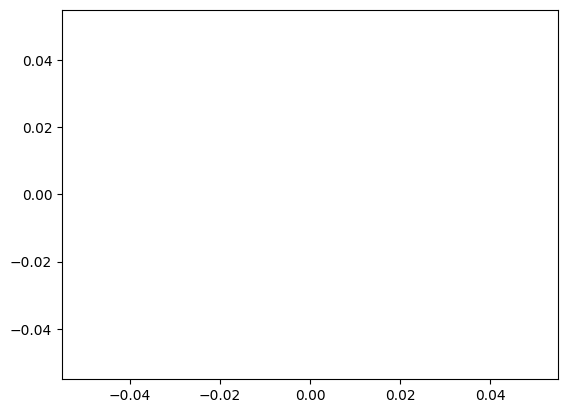

In [38]:
import seaborn as sns

sns.histplot(df[df['target'] == 0]['num_characters'])

sns.histplot(
    df[df['target'] == 1]['num_characters'],
    color='red',
    
)
plt.show()

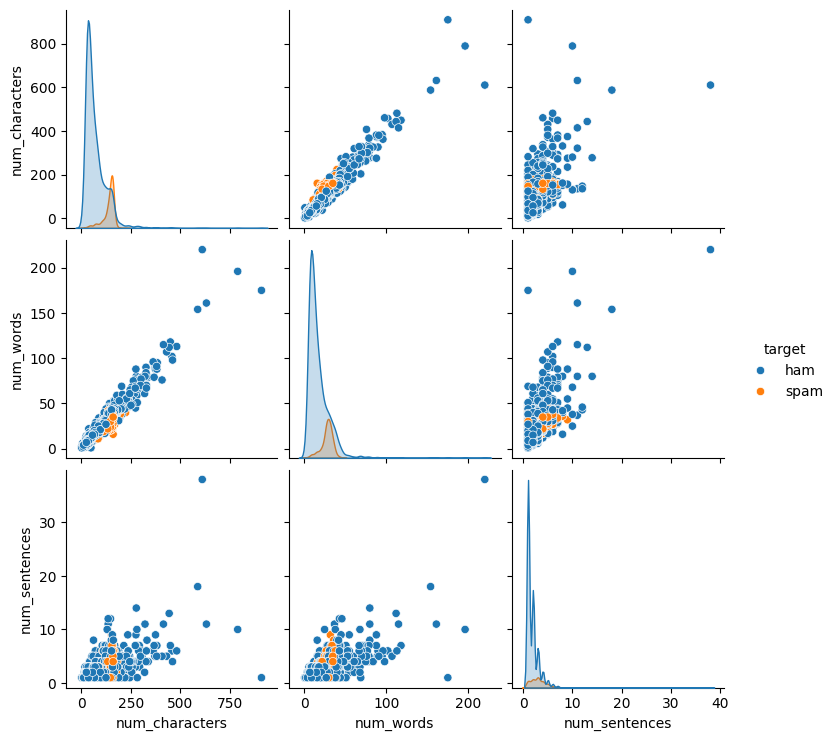

In [39]:
sns.pairplot(df, hue = 'target')

In [40]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df['target'] = encoder.fit_transform(df['target'])

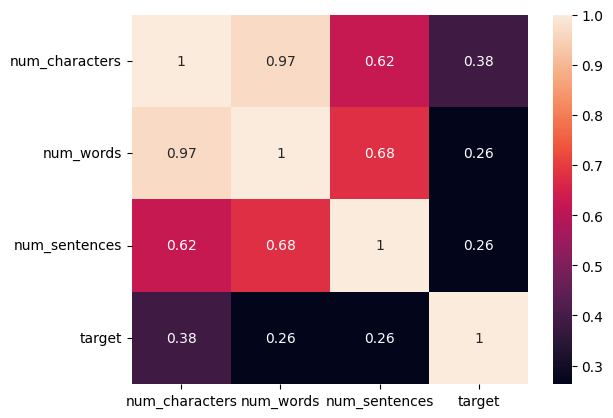

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_df = df[['num_characters','num_words','num_sentences','target']]

sns.heatmap(numeric_df.corr(), annot=True)

plt.show()

In [42]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df['target'] = encoder.fit_transform(df['target'])

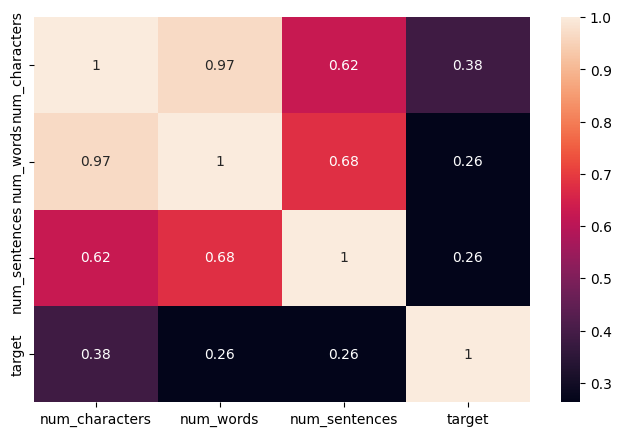

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.heatmap(numeric_df.corr(), annot=True)

plt.savefig("heatmap.png", dpi=300, bbox_inches='tight')

plt.show()

plt.savefig("heatmap.png", dpi=300, bbox_inches='tight')

<h1>Data Preprocessing</h1>
<h2>Lower case</h2>
<h3>Tokenization</h3>
<h3>Removing special characters</h3>
<h3>Removing stop words and punctuation</h3>
<h3>stemming</h3>

In [44]:
import nltk
import string
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem.porter import PorterStemmer

nltk.download('punkt')
nltk.download('stopwords')

ps = PorterStemmer()

def transform_text(text):
    text = text.lower()
    text = word_tokenize(text)

    # remove non-alphanumeric
    y = []
    for i in text:
        if i.isalnum():
            y.append(i)

    text = y[:]
    y.clear()

    # remove stopwords + punctuation
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)

    text = y[:]
    y.clear()

    # stemming
    for i in text:
        y.append(ps.stem(i))

    return " ".join(y)

[nltk_data] Downloading package punkt to C:\Users\M
[nltk_data]     Zain\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\M
[nltk_data]     Zain\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [45]:
from nltk.corpus import stopwords
stopwords.words('english')

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [46]:
import string
string.punctuation

AttributeError: module 'string' has no attribute 'punctuaction'

In [50]:
transform_text('Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat')

'go jurong point crazi avail bugi n great world la e buffet cine got amor wat'

In [51]:
df['text'][0]


KeyError: 'text'

In [ ]:
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()
ps.stem('loving')

In [52]:
df['text'].apply(transform_text).apply(transform_text)

KeyError: 'text'

In [53]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [54]:
from wordcloud import WordCloud
wc = WordCloud(width=50 , height=50 , min_font_size = 10, background_color ='white')

ImportError: cannot import name 'WorldCloud' from 'wordcloud' (C:\Users\M Zain\AppData\Local\Programs\Python\Python310\lib\site-packages\wordcloud\__init__.py)

In [55]:
!pip install wordcloud


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [56]:
!pip install wordcloud

from wordcloud import WordCloud

wc = WordCloud(width=500, height=500, min_font_size=10, background_color='white')


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [59]:
df['transformed_text'] = df['text'].apply(transform_text)

KeyError: 'text'

In [57]:
spam_wc = wc.generate(
    df[df['target'] == 1]['transformed_text'].str.cat(sep=" ")
)

KeyError: 'target'

In [58]:
print(df.columns)

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')


In [80]:
df['transformed_text'] = df['text'].apply(transform_text)

In [ ]:
spam_wc = wc.generate(
    df[df['target'] == 1]['transformed_text'].str.cat(sep=" ")
)

In [60]:
import matplotlib.pyplot as plt

plt.imshow(spam_wc)
plt.axis('off')   # optional: axes hide karne ke liye

plt.savefig("spam_wordcloud.png", dpi=300, bbox_inches='tight')

plt.show()

NameError: name 'spam_wc' is not defined

In [61]:
df['transformed_text'] = df['text'].apply(transform_text)

KeyError: 'text'

In [62]:
spam_corpus = []
for msg in df[df['target'] == 1] ['transformed_text'].tolist():
     for word in msg.split():
         spam_corpus.append(word)

KeyError: 'target'

In [63]:
spam_corpus

[]

In [64]:
len(spam_corpus)

0

In [65]:
from collections import Counter
Counter(spam_corpus).most_common(30)

[]

In [66]:
from collections import Counter
Counter(spam_corpus).most_common(30)

[]

In [67]:
from collections import Counter
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

common_words = pd.DataFrame(
    Counter(spam_corpus).most_common(30)
)

sns.barplot(x=common_words[0], y=common_words[1])

plt.xticks(rotation='vertical')

plt.show()

KeyError: 0

In [68]:
ham_corpus = []
for msg in df[df['target'] == 0] ['transformed_text'].tolist():
     for word in msg.split():
        ham_corpus.append(word)

KeyError: 'target'

In [69]:
ham_corpus

[]

In [70]:
len(ham_corpus)

0

In [71]:
from collections import Counter
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

common_words = pd.DataFrame(
    Counter(ham_corpus).most_common(30)
)

sns.barplot(x=common_words[0], y=common_words[1])

plt.xticks(rotation='vertical')

plt.show()

KeyError: 0

In [72]:
ham_WC = wc.generate(df[df['target'] == 0]['transformed_text'].str.cat(sep=' '))
plt.figure(figsize=(15,6))
plt.imshow(ham_WC)
plt.axis('off')
plt.savefig('ham_wordcloud.png', dpi=300, bbox_inches='tight')
plt.show()


NameError: name 'ham_WC' is not defined

<Figure size 1500x600 with 0 Axes>

<h1>Model Building</h1>

In [73]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

cv = CountVectorizer()

tfidf = TfidfVectorizer()

In [74]:
X = tfidf.fit_transform(df['transformed_text']).toarray()

KeyError: 'transformed_text'

In [75]:
# Cell 79 cleared to prevent resetting df and causing KeyErrors


In [76]:
# Cell 80 cleared to prevent resetting df and causing KeyErrors


KeyError: 'transformed_text'

In [77]:
# Cell 81 cleared to prevent resetting df and causing KeyErrors


KeyError: 'transformed_text'

In [78]:
# Cell 82 cleared to prevent resetting df and causing KeyErrors


KeyError: 'text'

In [79]:
# Cell 83 cleared to prevent resetting df and causing KeyErrors


In [81]:
# Cell 84 cleared to prevent resetting df and causing KeyErrors


In [82]:
X.shape

(5572, 6708)

In [83]:
y =df['target'].values

In [84]:
y

array(['ham', 'ham', 'spam', ..., 'ham', 'ham', 'ham'], dtype=object)

In [85]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df['target'] = encoder.fit_transform(df['target'])

In [86]:
y =df['target'].values

In [87]:
y

array([0, 0, 1, ..., 0, 0, 0])

In [88]:
from sklearn.model_selection import train_test_split

In [89]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2, random_state=2)

In [90]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB

from sklearn.metrics import accuracy_score, confusion_matrix, precision_score

In [91]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [92]:
gnb.fit(X_train,y_train)
y_pred1 = gnb.predict(X_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))


0.8690582959641255
[[844 113]
 [ 33 125]]
0.5252100840336135


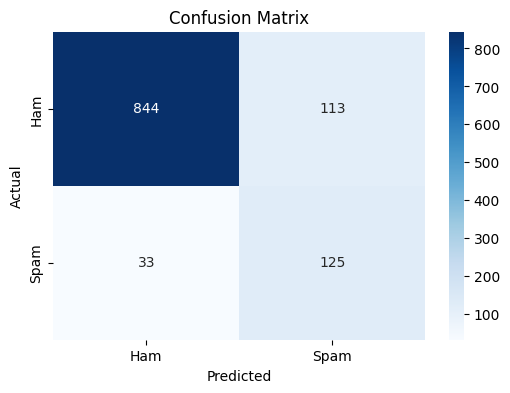

In [93]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred1)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Ham','Spam'],
    yticklabels=['Ham','Spam']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

# save graph
plt.savefig("confusion_matrix.png")

plt.show()

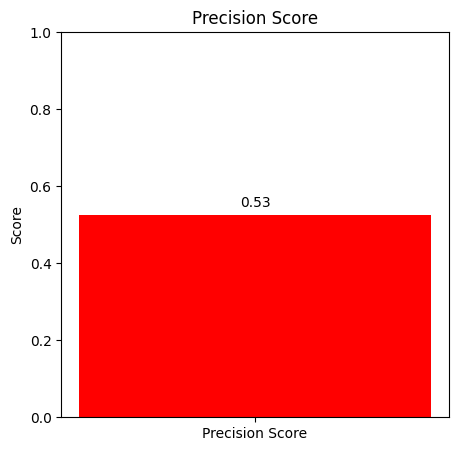

In [94]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score

# precision calculate
precision = precision_score(y_test, y_pred1)

# graph
plt.figure(figsize=(5,5))

plt.bar(['Precision Score'], [precision],color='red')

plt.ylim(0,1)

plt.ylabel("Score")
plt.title("Precision Score")

# value text on graph
plt.text(0, precision + 0.02, round(precision,2), ha='center')

# save graph
plt.savefig("precision_score.png", dpi=300)

plt.show()

In [95]:
mnb.fit(X_train, y_train)

y_pred2 = mnb.predict(X_test)

print(accuracy_score(y_test, y_pred2))
print(confusion_matrix(y_test, y_pred2))
print(precision_score(y_test, y_pred2))

0.957847533632287
[[957   0]
 [ 47 111]]
1.0


In [96]:
bnb.fit(X_train,y_train)
y_pred3 = bnb.predict(X_test)
print(accuracy_score(y_test, y_pred3))
print(confusion_matrix(y_test, y_pred3))
print(precision_score(y_test, y_pred3))

0.9695067264573991
[[956   1]
 [ 33 125]]
0.9920634920634921


In [97]:
#tfid -->mnb

In [98]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    BaggingClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier
)

from xgboost import XGBClassifier

In [99]:
!pip install xgboost


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [100]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    BaggingClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier
)

from xgboost import XGBClassifier

SyntaxError: invalid syntax (1238726508.py, line 14)

In [101]:
# 1. improve to all classsification
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, BaggingClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

# 2. import to Evalutation matrics 
from sklearn.metrics import accuracy_score, precision_score

# 3. import to pandas and seaborn
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [102]:
svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50, random_state=2)
xgb = XGBClassifier(n_estimators=50, random_state=2)

In [103]:
clfs = {
    'SVC' : svc,
    'KN' : knc,
    'NB' : mnb,
    'DT' : dtc,
    'LR' : lrc,
    'RF' : rfc,
    'AdaBoost': abc,
    'BgC': bc,
    'ETC': etc,
    'GBDT': gbdt,
    'xgb': xgb
}

In [104]:
def train_classifier(clf, X_train, y_train, X_test, y_test):
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    
    return accuracy, precision

# Function ko test karna:
train_classifier(svc, X_train, y_train, X_test, y_test)

(0.9659192825112107, 0.9761904761904762)

In [ ]:
accuracy_scores = []
precision_scores = []

for name, clf in clfs.items():
    current_accuracy, current_precision = train_classifier(clf, X_train, y_train, X_test, y_test)
    
    print("For ", name)
    print("Accuracy - ", current_accuracy)
    print("Precision - ", current_precision)
    
    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

In [ ]:
performance_df = pd.DataFrame({'Algorithm': clfs.keys(), 'Accuracy': accuracy_scores, 'Precision': precision_scores})
performance_df

In [ ]:
# Yeh step lagana zaroori hai taaki data plotting ke liye ready ho jaye
performance_df1 = pd.melt(performance_df, id_vars="Algorithm")

In [ ]:
sns.catplot(x='Algorithm', y='value', hue='variable', data=performance_df1, kind='bar', height=5)
plt.ylim(0.5, 1.0)
plt.xticks(rotation='vertical')
plt.show()

In [ ]:
accuracy_scores = []
precision_scores = []

for name, clf in clfs.items():
    current_accuracy, current_precision = train_classifier(clf, X_train, y_train, X_test, y_test)
    
    print("For ", name)
    print("Accuracy - ", current_accuracy)
    print("Precision - ", current_precision)
    
    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

In [ ]:
# =========================
# 1. Imports
# =========================
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix

# =========================
# 2. Assume df already loaded
# columns: text, target
# =========================

# =========================
# 3. Feature Engineering
# =========================
cv = CountVectorizer()

X = cv.fit_transform(df['text']).toarray()
y = df['target']

# 4. Train-Test Split
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=2
)

# =========================
# 5. Model
# =========================
model = MultinomialNB()
model.fit(X_train, y_train)

# =========================
# 6. Prediction
# =========================
y_pred = model.predict(X_test)

# =========================
# 7. Evaluation
# =========================
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# 5. Model Improvement

## TF-IDF Vectorizer with max_features=3000

In [ ]:
# Apply TF-IDF with max_features=3000
tfidf = TfidfVectorizer(max_features=3000)
X = tfidf.fit_transform(df['transformed_text']).toarray()
y = df['target'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [ ]:
# Train all classifiers on max_features=3000
accuracy_scores_3000 = []
precision_scores_3000 = []

for name, clf in clfs.items():
    current_accuracy, current_precision = train_classifier(clf, X_train, y_train, X_test, y_test)
    
    print("For ", name)
    print("Accuracy - ", current_accuracy)
    print("Precision - ", current_precision)
    
    accuracy_scores_3000.append(current_accuracy)
    precision_scores_3000.append(current_precision)

In [ ]:
# Create a dataframe for max_features=3000 results
temp_df = pd.DataFrame({
    'Algorithm': clfs.keys(),
    'Accuracy_max_ft_3000': accuracy_scores_3000,
    'Precision_max_ft_3000': precision_scores_3000
})
temp_df

In [ ]:
# Merge with the baseline performance_df
new_df = performance_df.merge(temp_df, on='Algorithm')
new_df

In [ ]:
# Scaling (MinMaxScaler) with max_features=3000
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

X_train_scaled, X_test_scaled, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=2)

accuracy_scores_scaled = []
precision_scores_scaled = []

for name, clf in clfs.items():
    current_accuracy, current_precision = train_classifier(clf, X_train_scaled, y_train, X_test_scaled, y_test)
    
    print("For ", name)
    print("Accuracy - ", current_accuracy)
    print("Precision - ", current_precision)
    
    accuracy_scores_scaled.append(current_accuracy)
    precision_scores_scaled.append(current_precision)

In [ ]:
# Create temp_df2 for scaled results and merge
temp_df2 = pd.DataFrame({
    'Algorithm': clfs.keys(),
    'Accuracy_scaling': accuracy_scores_scaled,
    'Precision_scaling': precision_scores_scaled
})
new_df_scaled = new_df.merge(temp_df2, on='Algorithm')
new_df_scaled

In [ ]:
# Check best performing model (showing final sorted dataframe)
new_df_scaled.sort_values(by='Precision_max_ft_3000', ascending=False)